# Hyperfine + Zeeman structure of an arbitrary $^{87}$Rb state

Generalizes the machinery in `transition_matrix_elements.ipynb` from the three D-line
states to **any** $^{87}$Rb fine-structure level $n\,^{2S+1}L_J$.

Given a state's hyperfine constants $A_{hfs}$, $B_{hfs}$, this builds

$$H(B) \;=\; \underbrace{A_{hfs}\,\frac{K}{2} + B_{hfs}\,(\ldots)}_{H_{hfs}}
\;+\; \underbrace{\mu_B\left(g_J J_z + g_I I_z\right)}_{H_Z}\,B$$

in the $|F, m_F\rangle$ basis, diagonalizes it on a field grid, and returns
eigenvalues and eigenvectors **in Hamiltonian-basis order** — column `i` is always the state labelled `(F[i], M[i])`, at every field.

Scope: the coupled $\leftrightarrow$ uncoupled basis transformation, and its use to build and diagonalize $H(B)$. Transition amplitudes built on top of these eigenvectors live in `transition_matrix_elements.ipynb`.

### Assumptions
- $^{87}$Rb, so $I = 3/2$; field along $z$.
- One $J$ manifold at a time, with $g_L L_z + g_S S_z \to g_J J_z$. Two separate
  points hide in that substitution:
  - *Within* a given $J$, the replacement is **exact**, not an approximation — it is the
    projection theorem, and $\langle J m|g_L L_z + g_S S_z|J m'\rangle
    = g_J\langle J m|J_z|J m'\rangle$ holds to machine precision.
  - The approximation is the **truncation to a single $J$**. The full operator also has
    matrix elements between $J$ and $J\pm1$ of the same term
    ($|\langle 3/2|g_LL_z+g_SS_z|1/2\rangle| = 0.4725\,\mu_B B$ for a $P$ term), and
    those are dropped. The resulting error is second order, growing as
    $(\mu_B B)^2/\Delta E_\text{FS}$.
  - For **S states there is no error at all**: $L=0$, so $J=1/2$ is the only $J$ in the
    term and there is nothing to mix with, at any field.
  - For **P states it is negligible** over any field used here. $\Delta E_\text{FS} =
    7.12$ THz for $5P$, giving 0.0043 MHz at the plotted $5P_{3/2}$ range and 0.55 MHz
    even at 3 kG — 0.1% of the hyperfine structure. It reaches 1% of the structure only
    near 9 kG ($5P_{3/2}$) or 12 kG ($5P_{1/2}$); for $6P$, near 3 kG.
- Magnetic dipole ($A$) and electric quadrupole ($B$) only; the magnetic octupole
  $C_{hfs}$ is neglected.

### Why this notebook builds $H_Z$ the way it does
$H_Z$ is assembled where it is *diagonal* — the uncoupled $|m_J, m_I\rangle$ basis — and
rotated into $|F, m_F\rangle$ with Clebsch-Gordan coefficients. That sidesteps
reduced-matrix phase conventions entirely, which is why this notebook was unaffected by
the coupling-order bug that had to be fixed in `transition_matrix_elements.ipynb` and
served as the reference for diagnosing it. See `ASSESSMENT_get_I_term.md` for the full
account of that bug and of the two routes.

## 1. Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sympy.physics.quantum.cg import CG
from sympy import Rational
from scipy import linalg

# --- physical constants (SI) ---
h    = 6.62607015e-34          # J s   (exact, SI definition)
hbar = h/(2*np.pi)
u_B  = 9.2740100657e-24        # J/T   Bohr magneton, CODATA 2022
MHz  = 1e6

# --- 87Rb + free-particle g-factors (Steck, Rubidium 87 D Line Data) ---
I_RB87 = 3/2                   # nuclear spin
S_E    = 1/2                   # electron spin
g_L    = 0.99999339            # orbital
g_S    = 2.0023193043622       # electron spin
g_I    = -0.0009951414         # nuclear (sign included; relative to mu_B)


def lande_gJ(L, S, J):
    """Lande g-factor of the fine-structure level."""
    return (g_L*(J*(J+1) - S*(S+1) + L*(L+1))/(2*J*(J+1))
            + g_S*(J*(J+1) + S*(S+1) - L*(L+1))/(2*J*(J+1)))


def lande_gF(F, I, J, gJ):
    """Low-field g-factor of the hyperfine level (F = 0 has no linear Zeeman shift)."""
    if F == 0:
        return 0.0
    return (gJ*(F*(F+1) - I*(I+1) + J*(J+1))/(2*F*(F+1))
            + g_I*(F*(F+1) + I*(I+1) - J*(J+1))/(2*F*(F+1)))

## 2. The coupled $\leftrightarrow$ uncoupled transformation

### Two bases for the same space


Same space, same dimension — just two different orthonormal bases for it.

**uncoupled** $\lvert m_J, m_I\rangle \equiv \lvert J m_J\rangle \otimes \lvert I m_I\rangle$ 
- Dimension: $(2J+1)(2I+1)$ 

**coupled**  $\lvert F, m_F\rangle$, $F = \lvert I-J\rvert \ldots I+J$ 

- Dimension: $\sum_F (2F+1) = (2J+1)(2I+1)$ 



### Each half of $H$ is diagonal in a *different* one

$$H_{hfs} \propto \vec I \cdot \vec J = \tfrac12\big(\vec F^2 - \vec I^2 - \vec J^2\big)
\qquad\Longrightarrow\qquad \textbf{diagonal in } \lvert F, m_F\rangle$$

$$H_Z \propto g_J J_z + g_I I_z
\qquad\Longrightarrow\qquad \textbf{diagonal in } \lvert m_J, m_I\rangle$$

Neither is diagonal in both, which is exactly why the problem needs numerics at
intermediate field. The strategy: build **each term in the basis where it is diagonal**
— so its matrix elements are read off with no angular-momentum algebra at all — then
rotate one into the other.

### The transformation matrix



$$\lvert F, M\rangle = \sum_{m_J, m_I} \langle J m_J\, I m_I \vert F M\rangle\;
\lvert m_J, m_I\rangle
\qquad\Longleftrightarrow\qquad
T_{ab} = \langle m_J^{(a)}, m_I^{(a)} \vert F_b, M_b\rangle$$

`cg_transform(I, J)` builds $T$: rows index the uncoupled basis, columns the coupled one.
Two properties make it usable, both checked numerically below:

1. **$T$ is real orthogonal**, $T^{\mathsf T}T = TT^{\mathsf T} = \mathbb{1}$. Clebsch–Gordan
   coefficients are real in the standard convention, so the change of basis is a rotation.
   An operator therefore transforms as
   $$A^{\text{coupled}} = T^{\mathsf T}\,A^{\text{uncoupled}}\,T$$
   and for a *diagonal* $A^{\text{unc}} = \mathrm{diag}(d)$ this collapses to
   $A^{\text{coup}}_{bc} = \sum_a T_{ab}\,d_a\,T_{ac}$ — the one line
   `T.T @ (d[:, None]*T)` in `couple_operator`.

2. **$T_{ab} = 0$ unless $m_J + m_I = M$.** The CG coefficient vanishes when the
   projections do not add up. This single fact is the origin of every structural property
   used later: it makes $H$ **block diagonal in $m_F$** (section 4), which is what lets each
   block be diagonalized separately and what makes each eigenvector's $m_F$ exact at any
   field.

### Why this route avoids the phase-convention trap

The alternative — the route `transition_matrix_elements.ipynb` uses — computes reduced
matrix elements $\langle F\Vert T^1(\vec V)\Vert F'\rangle$ via the spectator theorem. That
works, but the theorem's phase depends on the coupling order, and its hypothesis *forces*
a different order for $I_z$ than for $L_z, S_z$ (see `ASSESSMENT_get_I_term.md`). Each
operator's convention is
therefore set independently, and two of them disagreeing is invisible on the diagonal.

Here there is no reduced matrix element anywhere. $J_z$ and $I_z$ are written out
elementwise in the basis where they are trivially diagonal — entries $m_J$ and $m_I$, no
6j symbols, no phases to get wrong. The only convention in play is the CG sign convention,
and it enters in exactly one place, `cg_transform`, which every operator is routed
through. There is no opportunity for two terms to disagree.

**One choice is still being made:** taking $T$ from `CG(J, mJ, I, mI, F, M)` rather than
`CG(I, mI, J, mJ, F, M)` selects the $\lvert (J\,I)F\rangle$ coupling order over
$\lvert (I\,J)F\rangle$. That is a genuine convention — but it is made *once*, in *one
function*, and applies uniformly. Consistency is structural rather than something each
term has to be checked for.

In [2]:
def create_FM_arrays(I, J):
    '''Coupled basis in fixed order: F = |I-J| .. I+J, and M = -F .. +F within each F.'''
    F_array, M_array = [], []
    for F in np.arange(abs(I-J), I+J+1):
        F_array.extend([F]*int(2*F+1))
        M_array.extend(np.arange(-F, F+1))
    return np.array(F_array), np.array(M_array)


def _rat(x):
    '''Exact Rational for a (half-)integer float, so sympy's CG stays symbolic.'''
    return Rational(round(2*x), 2)


def uncoupled_basis(I, J):
    '''|m_J, m_I> in a fixed order.'''
    return [(mJ, mI) for mJ in np.arange(-J, J+1) for mI in np.arange(-I, I+1)]


def cg_transform(I, J):
    '''T[a, b] = <m_J, m_I | F, M>.  Rows: uncoupled basis.  Columns: coupled basis.

    This is the ONLY place a coupling convention is chosen -- CG(J, mJ, I, mI, ...)
    fixes the |(J I)F> order.  Every operator is routed through here, so consistency
    is structural rather than per-term.'''
    F, M = create_FM_arrays(I, J)
    unc = uncoupled_basis(I, J)
    T = np.zeros((len(unc), len(F)))
    for a, (mJ, mI) in enumerate(unc):
        for b in range(len(F)):
            if abs(mJ + mI - M[b]) > 1e-9:     # CG vanishes unless m_J + m_I = m_F
                continue
            T[a, b] = float(CG(_rat(J), _rat(mJ), _rat(I), _rat(mI),
                               _rat(F[b]), _rat(M[b])).doit())
    return T


def couple_operator(diag_uncoupled, I, J, T=None):
    '''Rotate an operator that is DIAGONAL in |m_J, m_I> into the |F, m_F> basis:
           A_coupled = T^T diag(d) T
    `diag_uncoupled` is the list of diagonal entries in uncoupled_basis(I, J) order.'''
    T = cg_transform(I, J) if T is None else T
    d = np.asarray(diag_uncoupled, dtype=float)
    return T.T @ (d[:, None]*T)

In [3]:
# --- properties of T, and a check of the transformation on something with a known
# --- closed form (I.J), independent of anything Zeeman.
for nm, (I, J) in {'5S1/2': (3/2, 1/2), '5P3/2': (3/2, 3/2), '5D5/2': (3/2, 5/2)}.items():
    F, M = create_FM_arrays(I, J)
    unc = uncoupled_basis(I, J)
    T = cg_transform(I, J)
    n = len(F)

    orth = max(np.abs(T.T @ T - np.eye(n)).max(), np.abs(T @ T.T - np.eye(n)).max())

    # property 2: T[a,b] = 0 unless m_J + m_I = M
    leak = max((abs(T[a, b]) for a, (mJ, mI) in enumerate(unc) for b in range(n)
                if abs(mJ + mI - M[b]) > 1e-9), default=0.0)

    # I.J is diagonal in the COUPLED basis with the Casimir value; build it in the
    # UNCOUPLED basis and rotate, then compare.  I.J = Iz Jz + (I+ J- + I- J+)/2, so it
    # is not diagonal in |m_J, m_I> -- do it as the full matrix, not via couple_operator.
    IJ_unc = np.zeros((n, n))
    for a, (mJ, mI) in enumerate(unc):
        for b, (mJp, mIp) in enumerate(unc):
            if (mJ, mI) == (mJp, mIp):
                IJ_unc[a, b] = mJ*mI
            elif abs(mJ - mJp - 1) < 1e-9 and abs(mI - mIp + 1) < 1e-9:
                IJ_unc[a, b] = 0.5*np.sqrt(J*(J+1) - mJp*(mJp+1))*np.sqrt(I*(I+1) - mIp*(mIp-1))
            elif abs(mJ - mJp + 1) < 1e-9 and abs(mI - mIp - 1) < 1e-9:
                IJ_unc[a, b] = 0.5*np.sqrt(J*(J+1) - mJp*(mJp-1))*np.sqrt(I*(I+1) - mIp*(mIp+1))
    IJ_coup = T.T @ IJ_unc @ T
    casimir = np.diag([(f*(f+1) - I*(I+1) - J*(J+1))/2 for f in F])
    ij_err = np.abs(IJ_coup - casimir).max()

    print(f'{nm:7s} dim {n:2d}   |T^T T - 1| = {orth:.1e}   '
          f'off-block leakage = {leak:.1e}   '
          f'|T^T (I.J) T - Casimir| = {ij_err:.1e}')

print('\n-> T is orthogonal, strictly block diagonal in m_F, and rotating I.J from the')
print('   uncoupled basis reproduces (F(F+1) - I(I+1) - J(J+1))/2 exactly.  The')
print('   transformation is doing what it claims, checked against a closed form that')
print('   involves no Zeeman physics at all.')

# an explicit look at one block
I, J = 3/2, 1/2
F, M = create_FM_arrays(I, J)
unc, T = uncoupled_basis(I, J), cg_transform(I, J)
rows = [a for a, (mJ, mI) in enumerate(unc) if abs(mJ + mI) < 1e-9]
cols = [b for b in range(len(F)) if abs(M[b]) < 1e-9]
print(f'\n5S1/2, the m_F = 0 block of T (2x2 -- only F=1 and F=2 have an m_F = 0):')
print(f'{"":22s}' + ''.join(f'|F={F[b]:.0f},M=0>'.rjust(12) for b in cols))
for a in rows:
    mJ, mI = unc[a]
    print(f'   <mJ={mJ:+.1f}, mI={mI:+.1f}|' + ''.join(f'{T[a, b]:12.5f}' for b in cols))
print('   (the +-1/sqrt2 singlet/triplet-like combinations; see ASSESSMENT_get_I_term.md)')

5S1/2   dim  8   |T^T T - 1| = 2.2e-16   off-block leakage = 0.0e+00   |T^T (I.J) T - Casimir| = 2.2e-16
5P3/2   dim 16   |T^T T - 1| = 2.2e-16   off-block leakage = 0.0e+00   |T^T (I.J) T - Casimir| = 4.4e-16
5D5/2   dim 24   |T^T T - 1| = 2.2e-16   off-block leakage = 0.0e+00   |T^T (I.J) T - Casimir| = 5.0e-16

-> T is orthogonal, strictly block diagonal in m_F, and rotating I.J from the
   uncoupled basis reproduces (F(F+1) - I(I+1) - J(J+1))/2 exactly.  The
   transformation is doing what it claims, checked against a closed form that
   involves no Zeeman physics at all.

5S1/2, the m_F = 0 block of T (2x2 -- only F=1 and F=2 have an m_F = 0):
                         |F=1,M=0>   |F=2,M=0>
   <mJ=-0.5, mI=+0.5|    -0.70711     0.70711
   <mJ=+0.5, mI=-0.5|     0.70711     0.70711
   (the +-1/sqrt2 singlet/triplet-like combinations; see ASSESSMENT_get_I_term.md)


## 3. The Hamiltonian

$H(B) = H_{hfs} + B\,H_Z$ is *exactly* linear in $B$, so both pieces are built once and
the field loop becomes a single array add.

The **quadrupole** term needs $I \ge 1$ **and** $J \ge 1$ — its denominator
$4I(2I-1)J(2J-1)$ vanishes at $J = 1/2$. The D-line notebook only tested `B_hfs != 0`,
which happens to work there; here it is guarded properly so a bad data entry raises
instead of dividing by zero.

In [4]:
def hyperfine_energy(F, I, J, A_hfs, B_hfs):
    """Casimir formula: magnetic dipole + electric quadrupole, relative to the centroid."""
    K = F*(F+1) - I*(I+1) - J*(J+1)
    E = A_hfs*K/2
    if B_hfs != 0:
        if I < 1 or J < 1:
            raise ValueError(
                f'B_hfs = {B_hfs/h/MHz:g} MHz given for I={I}, J={J}, but the electric '
                'quadrupole interaction vanishes identically unless I >= 1 and J >= 1.')
        E += B_hfs*(1.5*K*(K+1) - 2*I*(I+1)*J*(J+1))/(4*I*(2*I-1)*J*(2*J-1))
    return E


def get_H_components(I, J, L, S, A_hfs, B_hfs):
    """(H_hfs, H_Z) with H(B) = H_hfs + B*H_Z, in the (F, M) coupled basis order."""
    F, M = create_FM_arrays(I, J)

    # Hyperfine: diagonal in the coupled basis.
    H_hfs = np.diag([hyperfine_energy(f, I, J, A_hfs, B_hfs) for f in F])

    # Zeeman: diagonal in the uncoupled basis (entries g_J m_J + g_I m_I), then
    # rotated into the coupled one by section 2's couple_operator.
    gJ = lande_gJ(L, S, J)
    z = [gJ*mJ + g_I*mI for mJ, mI in uncoupled_basis(I, J)]
    H_Z = u_B*couple_operator(z, I, J)

    return H_hfs, H_Z


def suggest_B_max_T(state, factor=1.0):
    """A natural field scale for this state: where the Zeeman shift reaches `factor`
    times the full zero-field hyperfine spread.  Hyperfine structure ranges over three
    orders of magnitude across Rb87 (3.4 GHz for 5S1/2, a few MHz for 5D5/2), so a
    single hard-coded field range makes most diagrams unreadable."""
    E0 = [hyperfine_energy(f, state.I, state.J, state.A_hfs, state.B_hfs)
          for f in state.F_values]
    spread = max(E0) - min(E0) or h*MHz
    return factor*spread/(abs(state.gJ)*u_B)

## 4. Diagonalization, in basis order

`scipy.linalg.eigh` sorts by **energy**, which is not the basis order, so something has to
map eigen-index back to basis index. Section 2's property 2 does it, with no seeding and no
reference to neighbouring field points:

1. **$H$ is block diagonal in $m_F$**, because $T_{ab} = 0$ unless $m_J + m_I = M$. Each
   block is diagonalized on its own, so every eigenvector lies entirely inside one block
   and its $m_F$ is exact at any field.
2. **Within a block, levels never cross.** $H_Z$ is a rank-1 tensor, so $|F - F'| \le 1$:
   written in $F$ order each block is symmetric **tridiagonal**, and a tridiagonal matrix
   with non-zero off-diagonals is a *Jacobi matrix*, whose eigenvalues are **simple**.
   Levels in a block can never be degenerate, hence never cross, hence keep their energy
   rank for all $B$.

So: sort each block by energy and hand the $k$-th lowest to the basis state with the
$k$-th lowest **zero-field** energy. That is exact at $B = 0$ — $H(0) = H_{hfs}$ is
strictly diagonal there, so the eigenvector *is* the basis vector — and by (2) it stays
exact at every field.

Consequences worth noting:

- no seed is needed, and $B = 0$ need not be in the grid; the labelling at one field does
  not depend on any other field
- exactly independent of grid spacing (verified in section 6) and of the order
  `create_FM_arrays` happens to emit $F$ in
- it sorts on zero-field **energies**, not on $F$, so an inverted hyperfine structure
  ($A_{hfs} < 0$, e.g. $5D_{5/2}$) needs no special case

Levels of *different* $m_F$ cross freely; that is fine and invisible here, because blocks
are never compared with each other.

In [5]:
def get_M_blocks(F, M, E0):
    '''Basis indices of each m_F block, ordered by ZERO-FIELD energy (not by F).'''
    blocks = []
    for m in np.unique(M):
        rows = np.flatnonzero(M == m)
        blocks.append(rows[np.argsort(E0[rows], kind='stable')])
    return blocks


@dataclass
class ZeemanResult:
    '''Everything in BASIS order: index i always means the state (F[i], M[i]).'''
    state: object
    B: np.ndarray            # field grid, Tesla
    F: np.ndarray            # (n,)        F label of each index
    M: np.ndarray            # (n,)        m_F label of each index
    E: np.ndarray            # (nB, n)     energies, J, rel. to the hyperfine centroid
    V: np.ndarray            # (nB, n, n)  V[k, :, i] is state i at B[k]
    H_hfs: np.ndarray
    H_Z: np.ndarray

    @property
    def E_MHz(self):
        return self.E/h/MHz

    @property
    def labels(self):
        return [(int(f), int(m)) for f, m in zip(self.F, self.M)]

    def index(self, F, M):
        '''Index of |F, m_F>, for pulling one level out of E / V by label.'''
        hit = np.flatnonzero((self.F == F) & (self.M == M))
        if not len(hit):
            raise ValueError(f'{self.state.name} has no (F={F}, m_F={M}); available F '
                             f'are {sorted(set(self.F.astype(int)))}')
        return int(hit[0])

    def min_block_gap_MHz(self):
        '''Smallest gap between levels sharing an m_F, over the whole sweep.  Comfortably
        positive => no crossing occurred => the basis-order labels hold.'''
        gap = np.inf
        for rows in get_M_blocks(self.F, self.M, np.diag(self.H_hfs)):
            if len(rows) > 1:
                gap = min(gap, np.diff(self.E[:, rows], axis=1).min())
        return gap/h/MHz


def zeeman_structure(state, B):
    '''Diagonalize H(B) for `state` over the field grid `B` (Tesla), m_F block by
    m_F block, returning eigenvalues and eigenvectors in (F, M) basis order.'''
    B = np.atleast_1d(np.asarray(B, dtype=float))
    I, J, L, S = state.I, state.J, state.L, state.S
    F, M = create_FM_arrays(I, J)
    n = len(F)

    # Built ONCE: neither piece depends on B.
    H_hfs, H_Z = get_H_components(I, J, L, S, state.A_hfs, state.B_hfs)
    blocks = get_M_blocks(F, M, np.diag(H_hfs))

    E = np.empty((len(B), n))
    V = np.zeros((len(B), n, n))          # zeros: off-block entries stay exactly 0
    for k, B_val in enumerate(B):
        H = H_hfs + B_val*H_Z
        for rows in blocks:
            E[k, rows], V[k][np.ix_(rows, rows)] = linalg.eigh(H[np.ix_(rows, rows)])
        if k:
            # eigh's sign per column is arbitrary; keep it continuous in B so overlaps
            # <psi(B_k)|psi(B_k-1)> stay meaningful downstream.
            s = np.sign(np.einsum('ij,ij->j', V[k], V[k-1]))
            s[s == 0] = 1.0
            V[k] *= s

    return ZeemanResult(state, B, F, M, E, V, H_hfs, H_Z)

## 5. $^{87}$Rb state data

⚠️ **Hyperfine constants are physical input, not something this notebook derives.**
Only the three D-line states are `verified=True` — those are the Steck values the existing
`transition_matrix_elements.ipynb` already uses. Everything else is a commonly-quoted
literature number that **you must check against your own source**; constructing one prints
a warning.

Note the $5P_{1/2}$ discrepancy recorded in the `source` field.

In [6]:
@dataclass
class Rb87State:
    name: str
    n: int
    L: int                       # 0=S, 1=P, 2=D, 3=F
    J: float
    A_hfs_MHz: float
    B_hfs_MHz: float = 0.0
    source: str = ''
    verified: bool = False
    I: float = I_RB87
    S: float = S_E

    @property
    def A_hfs(self):
        return self.A_hfs_MHz*h*MHz              # Joules

    @property
    def B_hfs(self):
        return self.B_hfs_MHz*h*MHz              # Joules

    @property
    def F_values(self):
        return np.arange(abs(self.I-self.J), self.I+self.J+1)

    @property
    def gJ(self):
        return lande_gJ(self.L, self.S, self.J)

    @property
    def term(self):
        J = f'{round(2*self.J)}/2' if self.J % 1 else f'{self.J:g}'
        return f'{self.n}^2{"SPDFGH"[self.L]}_{{{J}}}'

    def __post_init__(self):
        if not self.verified:
            print(f'  ! {self.name}: hyperfine constants UNVERIFIED '
                  f'({self.source or "no source recorded"}) -- check before use.')


RB87 = {}
def add_state(s):
    RB87[s.name] = s
    return s

# ---- verified: Steck, "Rubidium 87 D Line Data" (as used in the D-line notebook) ----
add_state(Rb87State('5S1/2', 5, 0, 1/2, 3417.341305452145, 0.0,
                    source='Steck, Rb87 D Line Data', verified=True))
add_state(Rb87State('5P1/2', 5, 1, 1/2, 407.25, 0.0,
                    source='value used in transition_matrix_elements.ipynb. NOTE Steck '
                           'quotes A = 408.328(15) MHz -> 816.656 MHz splitting, vs '
                           '814.50 MHz here. Reconcile before publishing.',
                    verified=True))
add_state(Rb87State('5P3/2', 5, 1, 3/2, 84.7185, 12.4965,
                    source='Steck, Rb87 D Line Data', verified=True))

Rb87State(name='5P3/2', n=5, L=1, J=1.5, A_hfs_MHz=84.7185, B_hfs_MHz=12.4965, source='Steck, Rb87 D Line Data', verified=True, I=1.5, S=0.5)

In [7]:
# ---- unverified literature values, for exploring higher states ---------------------
# Commonly quoted numbers, NOT checked against a primary source here.  Replace the value
# and set verified=True once you have confirmed it from your own reference.
add_state(Rb87State('6S1/2', 6, 0, 1/2, 807.66,  0.0,   source='commonly quoted; VERIFY'))
add_state(Rb87State('7S1/2', 7, 0, 1/2, 319.759, 0.0,   source='commonly quoted; VERIFY'))
add_state(Rb87State('6P1/2', 6, 1, 1/2, 132.56,  0.0,   source='commonly quoted; VERIFY'))
add_state(Rb87State('6P3/2', 6, 1, 3/2, 27.700,  3.953, source='commonly quoted; VERIFY'))
add_state(Rb87State('5D3/2', 5, 2, 3/2, 14.43,   2.86,  source='commonly quoted; VERIFY'))
add_state(Rb87State('5D5/2', 5, 2, 5/2, -2.1,    2.2,   source='commonly quoted; VERIFY -- A < 0, inverted structure'))

print()
for k, v in RB87.items():
    print(f'  {k:6s} {v.term:14s} F = {[int(f) for f in v.F_values]!s:16s} '
          f'g_J = {v.gJ:8.5f}  {"verified" if v.verified else "UNVERIFIED"}')

  ! 6S1/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY) -- check before use.
  ! 7S1/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY) -- check before use.
  ! 6P1/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY) -- check before use.
  ! 6P3/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY) -- check before use.
  ! 5D3/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY) -- check before use.
  ! 5D5/2: hyperfine constants UNVERIFIED (commonly quoted; VERIFY -- A < 0, inverted structure) -- check before use.

  5S1/2  5^2S_{1/2}     F = [1, 2]           g_J =  2.00232  verified
  5P1/2  5^2P_{1/2}     F = [1, 2]           g_J =  0.66588  verified
  5P3/2  5^2P_{3/2}     F = [0, 1, 2, 3]     g_J =  1.33410  verified
  6S1/2  6^2S_{1/2}     F = [1, 2]           g_J =  2.00232  UNVERIFIED
  7S1/2  7^2S_{1/2}     F = [1, 2]           g_J =  2.00232  UNVERIFIED
  6P1/2  6^2P_{1/2}     F = [1, 2]           g_J =  0.66588  UNVERIFIED
  6P3/2  6

## 6. Validation

Five checks. The first four compare against closed-form results the code does **not**
use internally, so agreement is meaningful rather than circular.

| check | compared against |
|---|---|
| zero-field energies | Casimir formula, evaluated independently |
| labelling | basis order, recomputed from the eigenvectors |
| low-field $dE/dB$ | $g_F\,m_F\,\mu_B$ (Landé) |
| energies at **all** fields, $J=1/2$ | exact **Breit-Rabi** solution |
| no level crossing | minimum gap between levels sharing $m_F$ |

The low-field slope test picks its own test field from the smallest hyperfine gap, so it
stays in the linear regime even for a state like $5D_{5/2}$ where $A$ is only a few MHz.

In [8]:
def breit_rabi(state, B, F, M):
    """Exact energies of a J=1/2 hyperfine doublet, relative to the centroid."""
    I, J = state.I, state.J
    assert J == 0.5, 'Breit-Rabi applies to J = 1/2 only'
    dE = state.A_hfs*(I + 0.5)                       # zero-field splitting
    x = (state.gJ - g_I)*u_B*B/dE
    base = -dE/(2*(2*I+1)) + g_I*u_B*M*B
    if abs(M) == I + 0.5:
        # Stretched states: 1 + 4Mx/(2I+1) + x^2 = (1 +- x)^2 exactly, and the physical
        # branch is the SIGNED root (linear in B for all B) -- not sqrt(), whose absolute
        # value would kink at x = 1.
        return base + (dE/2)*(1 + np.sign(M)*x)
    sign = +1 if F == I + 0.5 else -1
    return base + sign*(dE/2)*np.sqrt(1 + 4*M*x/(2*I+1) + x**2)


def validate(state, B_max_T=0.3, n=201, verbose=True):
    B = np.linspace(0, B_max_T, n)
    r = zeeman_structure(state, B)
    rows = []

    # (1) zero-field energies vs the Casimir formula
    d = max(abs(r.E[0, i] - hyperfine_energy(r.F[i], state.I, state.J,
                                             state.A_hfs, state.B_hfs))
            for i in range(len(r.F)))/h/MHz
    rows.append(('zero-field energies vs Casimir', f'{d:.2e} MHz'))

    # (2) labels recomputed from the eigenvectors == basis order
    w = r.V[0]**2
    ok = (np.allclose(w.T @ r.M, r.M)
          and np.allclose(r.F[np.argmax(w, axis=0)], r.F))
    rows.append(('eigenvector order == basis order', 'OK' if ok else 'BROKEN'))

    # (3) low-field slopes vs g_F m_F mu_B.  Pick B so the Zeeman energy is 1e-6 of the
    #     smallest zero-field hyperfine gap -- i.e. deep in the linear regime for ANY
    #     state, including ones with only a few MHz of hyperfine structure.
    E0 = np.unique(np.round(np.diag(r.H_hfs)/h/MHz, 9))
    gap = np.min(np.diff(E0)) if len(E0) > 1 else 1.0
    B_lin = 1e-6*gap*MHz*h/(abs(state.gJ)*u_B)
    rl = zeeman_structure(state, np.array([0.0, B_lin]))
    slope = (rl.E[1] - rl.E[0])/B_lin
    pred = np.array([lande_gF(f, state.I, state.J, state.gJ)*m*u_B
                     for f, m in zip(rl.F, rl.M)])
    d = np.abs(slope - pred).max()/max(np.abs(pred).max(), 1e-300)
    rows.append(('low-field dE/dB vs g_F m_F mu_B', f'{d:.2e} (relative)'))

    # (4) Breit-Rabi, exact for J = 1/2, at every field
    if state.J == 0.5:
        dmax = max(np.abs(r.E[:, i] - breit_rabi(state, B, r.F[i], r.M[i])).max()
                   for i in range(len(r.F)))/h/MHz
        rows.append(('all-field energies vs Breit-Rabi', f'{dmax:.2e} MHz'))
    else:
        rows.append(('all-field energies vs Breit-Rabi', 'n/a (J != 1/2)'))

    # (5) the one assumption the labelling rests on
    g = r.min_block_gap_MHz()
    rows.append(('min gap between levels sharing m_F',
                 'n/a (all blocks are singletons)' if not np.isfinite(g)
                 else f'{g:.3f} MHz'))

    if verbose:
        print(f'{state.name}  (${state.term}$,  A = {state.A_hfs_MHz:g} MHz, '
              f'B = {state.B_hfs_MHz:g} MHz,  g_J = {state.gJ:.5f})')
        print(f'  F = {[int(f) for f in state.F_values]},  {len(r.F)} sublevels,  '
              f'B up to {B_max_T*1e4:g} G')
        for k, v in rows:
            print(f'    {k:38s} {v}')
        print()
    return r


for nm in ['5S1/2', '5P1/2', '5P3/2']:
    validate(RB87[nm])

5S1/2  ($5^2S_{1/2}$,  A = 3417.34 MHz, B = 0 MHz,  g_J = 2.00232)
  F = [1, 2],  8 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        5.01e-07 (relative)
    all-field energies vs Breit-Rabi       3.33e-12 MHz
    min gap between levels sharing m_F     5919.018 MHz

5P1/2  ($5^2P_{1/2}$,  A = 407.25 MHz, B = 0 MHz,  g_J = 0.66588)
  F = [1, 2],  8 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        5.04e-07 (relative)
    all-field energies vs Breit-Rabi       8.32e-13 MHz
    min gap between levels sharing m_F     705.379 MHz

5P3/2  ($5^2P_{3/2}$,  A = 84.7185 MHz, B = 12.4965 MHz,  g_J = 1.33410)
  F = [0, 1, 2, 3],  16 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       O

In [9]:
# The same suite on higher states, to show nothing is specialized to the D line.
# 5D3/2 has an F=0 level; 5D5/2 has A < 0 (inverted hyperfine ordering).  Neither is
# special-cased anywhere.
for nm in ['6S1/2', '7S1/2', '6P3/2', '5D3/2', '5D5/2']:
    validate(RB87[nm])

6S1/2  ($6^2S_{1/2}$,  A = 807.66 MHz, B = 0 MHz,  g_J = 2.00232)
  F = [1, 2],  8 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        5.01e-07 (relative)
    all-field energies vs Breit-Rabi       2.77e-12 MHz
    min gap between levels sharing m_F     1398.934 MHz



7S1/2  ($7^2S_{1/2}$,  A = 319.759 MHz, B = 0 MHz,  g_J = 2.00232)
  F = [1, 2],  8 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        5.01e-07 (relative)
    all-field energies vs Breit-Rabi       2.22e-12 MHz
    min gap between levels sharing m_F     554.091 MHz

6P3/2  ($6^2P_{3/2}$,  A = 27.7 MHz, B = 3.953 MHz,  g_J = 1.33410)
  F = [0, 1, 2, 3],  16 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        8.35e-07 (relative)
    all-field energies vs Breit-Rabi       n/a (J != 1/2)
    min gap between levels sharing m_F     23.747 MHz

5D3/2  ($5^2D_{3/2}$,  A = 14.43 MHz, B = 2.86 MHz,  g_J = 0.79953)
  F = [0, 1, 2, 3],  16 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order    

5D5/2  ($5^2D_{5/2}$,  A = -2.1 MHz, B = 2.2 MHz,  g_J = 1.20046)


  F = [1, 2, 3, 4],  24 sublevels,  B up to 3000 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        4.21e-07 (relative)
    all-field energies vs Breit-Rabi       n/a (J != 1/2)
    min gap between levels sharing m_F     5.960 MHz



## 7. Energy diagrams

Colour carries $F$; every line is also directly labelled with its $m_F$, so identity never
depends on colour alone. In manifolds with many sublevels only $m_F = \pm F$ and $0$ are
labelled, to keep the right margin readable.

In [10]:
# Categorical palette in fixed order (blue, orange, aqua, yellow, magenta, green, violet,
# red), assigned by ascending F and never cycled.
SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                 '#e87ba4', '#008300', '#4a3aa7', '#e34948']


def _mF_text(m):
    return f'${m:+.0f}$' if round(m) != 0 else '$0$'


def plot_energy_diagram(result, B_max_G=None, ax=None, direct_labels='auto', title=None):
    """Zeeman diagram for one state; `result` comes from zeeman_structure()."""
    r = result
    B_G = r.B*1e4
    B_max_G = B_G[-1] if B_max_G is None else min(B_max_G, B_G[-1])
    k = int(np.searchsorted(B_G, B_max_G, side='right')) - 1
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5.5))

    F_vals = sorted(set(r.F))
    colors = {F: SERIES_COLORS[i % len(SERIES_COLORS)] for i, F in enumerate(F_vals)}
    if direct_labels == 'auto':
        direct_labels = 'all' if len(r.F) <= 16 else 'extremes'

    tags = []                                   # (y_at_right_edge, text, colour)
    for i in range(len(r.F)):
        F_i, m_i = r.F[i], r.M[i]
        E = r.E_MHz[:k+1, i]
        ax.plot(B_G[:k+1], E, '-', lw=2, color=colors[F_i],
                label=f'$F={F_i:.0f}$' if m_i == -F_i else None)
        if direct_labels == 'all' or (direct_labels == 'extremes'
                                      and abs(m_i) in (F_i, 0)):
            tags.append([E[-1], _mF_text(m_i), colors[F_i]])

    # Declutter: at high field many levels converge, so raw labels overprint.  Sweep
    # upward once and push each tag just far enough above its neighbour to stay legible.
    lo, hi = r.E_MHz[:k+1].min(), r.E_MHz[:k+1].max()
    min_sep = 0.030*(hi - lo)
    tags.sort(key=lambda t: t[0])
    for a in range(1, len(tags)):
        if tags[a][0] - tags[a-1][0] < min_sep:
            tags[a][0] = tags[a-1][0] + min_sep
    for y, text, colour in tags:
        ax.annotate(text, xy=(B_G[k], y), xytext=(5, 0), textcoords='offset points',
                    va='center', fontsize=9, fontweight='bold', color=colour)

    sub = f', $B$ = {r.state.B_hfs_MHz:g} MHz' if r.state.B_hfs_MHz else ''
    ax.set_title(title or f'${r.state.term}$   ($A$ = {r.state.A_hfs_MHz:g} MHz{sub})')
    ax.set_xlabel('Magnetic field (G)')
    ax.set_ylabel('Energy shift (MHz)')
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    ax.set_xlim([0, B_max_G*1.10])
    ax.set_ylim([lo - 0.09*(hi-lo), hi + 0.09*(hi-lo)])
    ax.legend(title='$m_F$ at right', loc='best', fontsize=9, framealpha=0.92)
    return ax

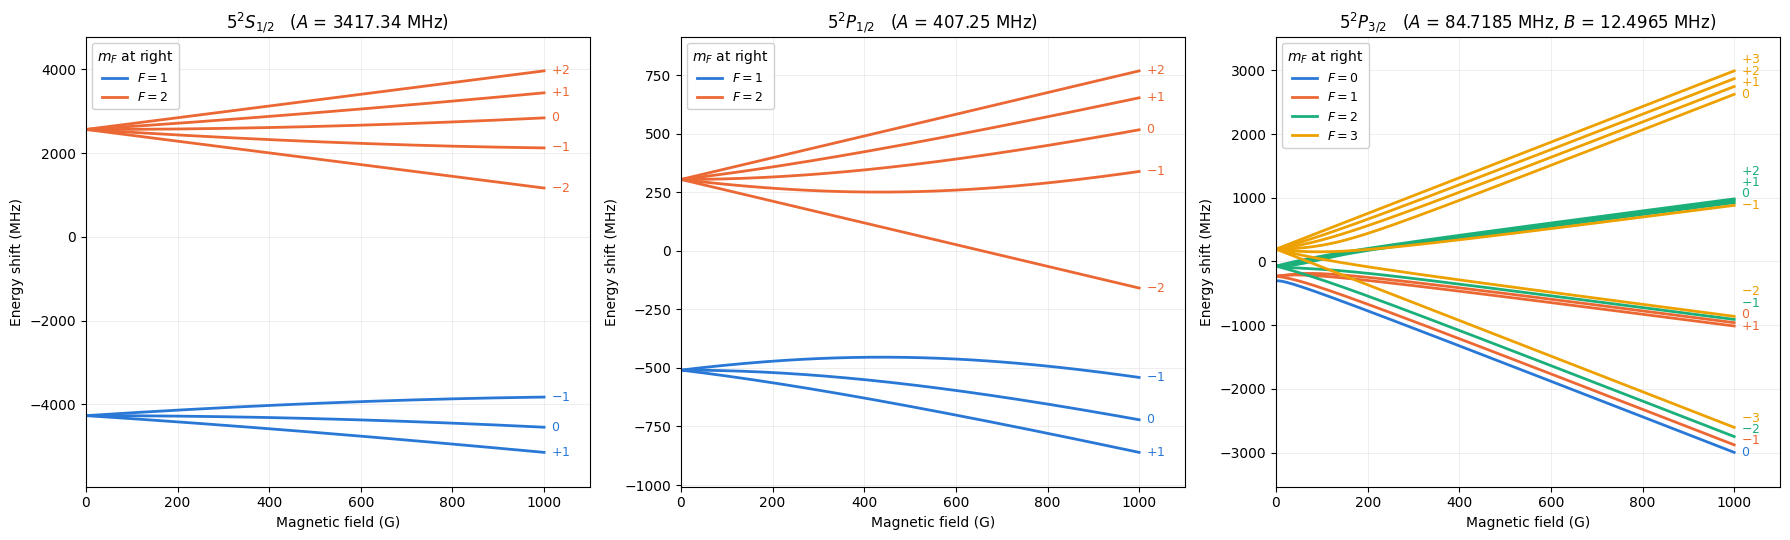

In [11]:
# The three D-line states, 0-1000 G
B = np.linspace(0, 0.30, 400)                     # Tesla
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, nm in zip(axs, ['5S1/2', '5P1/2', '5P3/2']):
    plot_energy_diagram(zeeman_structure(RB87[nm], B), B_max_G=1000, ax=ax)
fig.tight_layout()
plt.show()

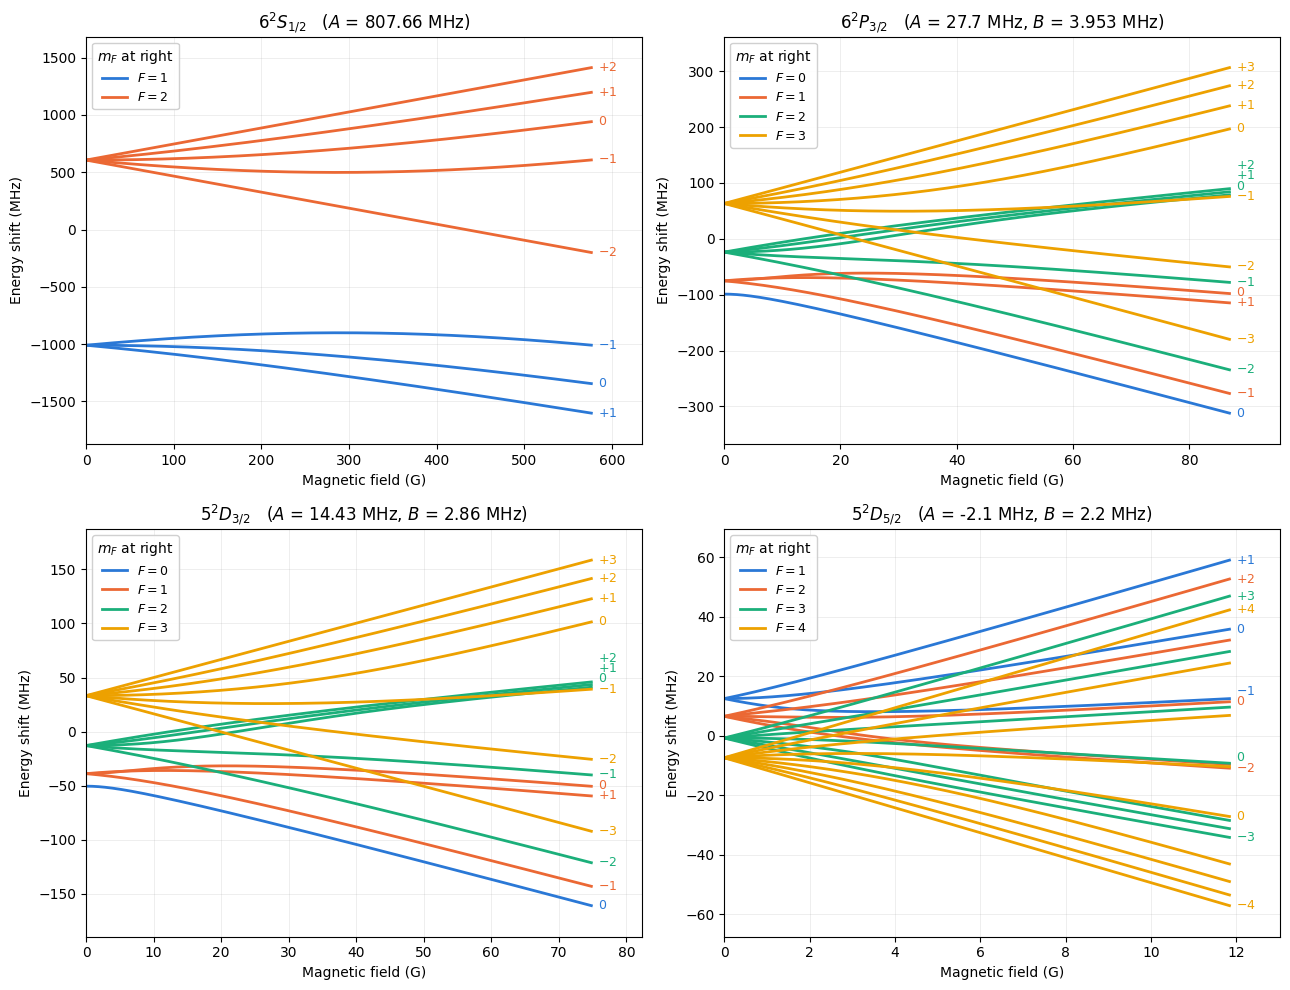

In [12]:
# Higher states.  Note 5D5/2 (A < 0): its F manifolds run the other way, and the code
# picks that up from the zero-field energies with no special case.
fig, axs = plt.subplots(2, 2, figsize=(13, 10))
for ax, nm in zip(axs.ravel(), ['6S1/2', '6P3/2', '5D3/2', '5D5/2']):
    st = RB87[nm]
    B_max = suggest_B_max_T(st)          # each state at its own natural field scale
    plot_energy_diagram(zeeman_structure(st, np.linspace(0, B_max, 400)), ax=ax)
fig.tight_layout()
plt.show()

## 8. Reading the stacking order off a diagram

For the D-line states the levels stack bottom-to-top as
$m_F = 1, 0, -1, -2, -1, 0, 1, 2$ — the $F=1$ manifold inverted ($g_F < 0$) below the
$F=2$ manifold ($g_F > 0$). `stacking_order()` reads that sequence straight off the
computed spectrum for any state, so a plotted diagram can be checked against expectation.

In [13]:
def stacking_order(result, B_G=None):
    """(F, m_F) of every level, bottom to top, at one field.  Defaults to the first
    non-zero field point -- at B = 0 the m_F sublevels are degenerate and their relative
    order is meaningless."""
    r = result
    k = 1 if B_G is None else int(np.argmin(np.abs(r.B*1e4 - B_G)))
    order = np.argsort(r.E[k])
    return [(int(r.F[i]), int(r.M[i])) for i in order], r.B[k]*1e4


for nm in ['5S1/2', '5P1/2', '5P3/2']:
    seq, at_G = stacking_order(zeeman_structure(RB87[nm], B), B_G=500)
    print(f'{nm:6s} at {at_G:6.1f} G, bottom -> top:')
    print(f'         m_F = {[m for _, m in seq]}')
    print(f'         F   = {[f for f, _ in seq]}')

5S1/2  at  503.8 G, bottom -> top:
         m_F = [1, 0, -1, -2, -1, 0, 1, 2]
         F   = [1, 1, 1, 2, 2, 2, 2, 2]
5P1/2  at  503.8 G, bottom -> top:
         m_F = [1, 0, -1, -2, -1, 0, 1, 2]
         F   = [1, 1, 1, 2, 2, 2, 2, 2]
5P3/2  at  503.8 G, bottom -> top:
         m_F = [0, -1, -2, -3, 1, 0, -1, -2, -1, 0, 1, 2, 0, 1, 2, 3]
         F   = [0, 1, 2, 3, 1, 1, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3]


## 9. Adding a state

Everything keys off `Rb87State`, so a new level needs only its quantum numbers and
hyperfine constants:

```python
my_state = Rb87State('8P3/2', 8, 1, 3/2, A_hfs_MHz=..., B_hfs_MHz=...,
                     source='your reference', verified=True)
r = zeeman_structure(my_state, np.linspace(0, 0.1, 200))
validate(my_state, B_max_T=0.1)
plot_energy_diagram(r)
```

Pull a specific sublevel out by label rather than by index — `r.index(F=2, M=0)` gives its
position in `r.E` / `r.V`.

  ! 4D5/2 (demo): hyperfine constants UNVERIFIED (DEMONSTRATION VALUES ONLY -- not a verified reference) -- check before use.


4D5/2 (demo)  ($4^2D_{5/2}$,  A = -7.44 MHz, B = 8.19 MHz,  g_J = 1.20046)
  F = [1, 2, 3, 4],  24 sublevels,  B up to 200 G
    zero-field energies vs Casimir         0.00e+00 MHz
    eigenvector order == basis order       OK
    low-field dE/dB vs g_F m_F mu_B        4.21e-07 (relative)
    all-field energies vs Breit-Rabi       n/a (J != 1/2)
    min gap between levels sharing m_F     18.522 MHz

|F=4, m_F=+4> is basis index 23:  E(0 G) = -25.852 MHz,  E(200 G) = +813.825 MHz


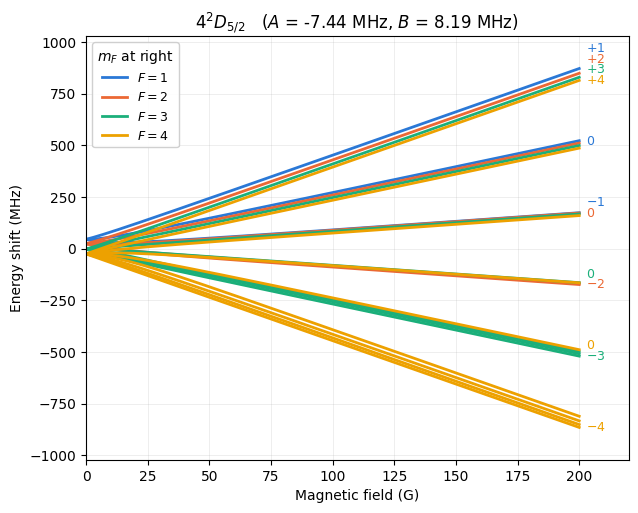

In [14]:
# Worked example: a state defined inline rather than taken from the RB87 table.
demo = Rb87State('4D5/2 (demo)', 4, 2, 5/2, A_hfs_MHz=-7.44, B_hfs_MHz=8.19,
                 source='DEMONSTRATION VALUES ONLY -- not a verified reference')
r_demo = zeeman_structure(demo, np.linspace(0, 0.02, 200))
validate(demo, B_max_T=0.02)

i = r_demo.index(F=4, M=4)                        # stretched state, addressed by label
print(f'|F=4, m_F=+4> is basis index {i}:  '
      f'E(0 G) = {r_demo.E_MHz[0, i]:+.3f} MHz,  '
      f'E(200 G) = {r_demo.E_MHz[-1, i]:+.3f} MHz')

plot_energy_diagram(r_demo)
plt.show()